# FP8（E4M3/E5M2）、MXFP4 与 GGUF k-quants：硬件数值格式 round-trip

> **PTQ 教学 demo 系列 · 08 / 13**
> 配套博客：[《GGUF k-quants、FP8 与 MXFP4：工程生态与硬件格式的量化》](https://lrypcy.github.io/2026/08/24/ptq-08-gguf-fp8-mxfp4/)（PTQ 深度系列 · 第 8 篇 · 收尾篇）

**一段话原理**：量化算法最终都要落到具体的数值格式上，而格式由硬件生态决定。**FP8** 是 IEEE 风格的 8-bit 浮点——E4M3（1 符号＋4 指数＋3 尾数，最大有限值 240）尾数多、精度高，E5M2（1＋5＋2，最大 57344）指数多、范围宽，本质是「用指数位换动态范围」，因此前向用 E4M3、反向用 E5M2；**MXFP4** 让每 32 个元素共享一个 E8M0 纯指数 scale $s=2^{\lfloor\log_2 \mathrm{amax}\rfloor-2}$，把「表示动态范围」的任务从单个 4-bit 元素身上剥离给块级 scale，元素本身只需查 E2M1 八级表 $\{0,\pm0.5,\pm1,\pm1.5,\pm2,\pm3,\pm4,\pm6\}$；**GGUF k-quants** 则代表 CPU 生态「组合位宽＋块级共享 scale」的工程路线，其块级共享思想与 MXFP4 的 E8M0 一脉相承——本 demo 以 QLoRA 的 NF4 分位数码本作为 4-bit 的信息论上限参照。以上全部用纯 numpy 位运算手工实现并横向评测。

## 第 1 步 · 工具箱：通用浮点格式仿真器

这步在做什么：导入依赖、固定 SEED=0，实现贯穿全篇的三件基础工具——SQNR 指标（信噪比，dB）、对称 INT8 均匀量化参照，以及核心的 `quant_float` 通用浮点仿真器：给定（指数位数、尾数位数、指数偏置），按「逐值定步长 → 半偶舍入 → 尾数进位修正 → 饱和/溢出」四步完成任意 $(e, m, \mathrm{bias})$ 格式的量化 round-trip，同时正确处理正规数与子正规数。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0   # 全局随机种子: 保证每次运行结果完全可复现


def sqnr_db(x, xq):
    """SQNR = 10*log10(信号功率 / 量化误差功率), 单位 dB."""
    err = np.asarray(x) - np.asarray(xq)
    return float(10.0 * np.log10(np.sum(x ** 2) / np.sum(err ** 2)))


def quant_int8_sym(x):
    """逐张量对称 INT8: s = max|x|/127, q = round(x/s)*s (均匀格点参照)."""
    s = np.max(np.abs(x)) / 127.0
    return np.round(x / s) * s


def quant_float(x, e_bits, m_bits, bias, saturate=False):
    """把 x round-trip 到 (e_bits 指数, m_bits 尾数, bias 偏置) 的浮点格式.

    值域布局 (IEEE 风格, 保留最高指数码给 NaN/Inf):
      正规数: (-1)^s * 2^(E-bias) * (1 + m/2^m_bits), E 属于 [1, 2^e_bits - 2]
      子正规: 步长固定为 2^(emin - m_bits), 其中 emin = 1 - bias
    舍入一律半偶 (np.round 即 round-half-to-even, 与 IEEE 一致);
    saturate=True 时溢出夹到最大有限值, 否则置 inf.
    """
    x = np.asarray(x, dtype=np.float64)
    emax = (2 ** e_bits - 2) - bias            # 最大正规指数 (无偏)
    emin = 1 - bias                            # 最小正规指数 (无偏)
    maxval = (2.0 - 2.0 ** (-m_bits)) * 2.0 ** emax
    sign = np.where(x < 0, -1.0, 1.0)
    ax = np.abs(x)
    out = np.zeros_like(ax)
    nz = ax > 0
    e_unb = np.zeros_like(ax)
    e_unb[nz] = np.floor(np.log2(ax[nz]))       # 各值所属 binade
    # 步长随 binade 指数翻倍; 跌入子正规带后固定为 2^(emin-m_bits)
    e_eff = np.clip(e_unb, emin, emax).astype(np.int64)
    step = 2.0 ** (e_eff - m_bits)
    q = np.round(ax / step) * step              # 半偶舍入到最近格点
    # 尾数进位: 舍入跨过 2 的幂 -> 落入上一 binade, 按新步长重算一次;
    # 下界 max(e_unb+1, emin) 同时覆盖 "子正规带舍入上探进正规区" 的边界
    cross = nz & (q >= 2.0 ** np.maximum(e_unb + 1.0, float(emin)))
    if np.any(cross):
        e_new = np.floor(np.log2(q[cross])).astype(np.int64)
        step2 = 2.0 ** (e_new - m_bits)
        q[cross] = np.round(ax[cross] / step2) * step2
    if saturate:
        q = np.minimum(q, maxval)
    else:
        q = np.where(q > maxval, np.inf, q)
    out[nz] = q[nz]
    return sign * out

## 第 2 步 · 合成数据：两种典型权重分布

这步在做什么：构造两个 $512\times512$ 的 toy 权重矩阵——零均值高斯 $\mathcal{N}(0,1)$（LLM 权重的经验分布）与单位方差拉普拉斯分布（重尾，用来放大「尾部大值撑大 scale」的效应）。固定种子保证后面每个格式的 SQNR 数字完全可复现。

In [2]:
rng = np.random.default_rng(SEED)
gauss = rng.standard_normal((512, 512))                      # 分布 A: 高斯 N(0, 1)
laplace = rng.laplace(0.0, 1.0 / np.sqrt(2.0), (512, 512))   # 分布 B: 拉普拉斯 (单位方差)

print("shape =", gauss.shape, " n_elements =", gauss.size)
for name, w in [("gauss", gauss), ("laplace", laplace)]:
    print(f"{name:8s} std = {w.std():.3f}   max|x| = {np.max(np.abs(w)):.2f}   "
          f"P(|x| > 3*std) = {np.mean(np.abs(w) > 3 * w.std()):.4f}")

shape = (512, 512)  n_elements = 262144
gauss    std = 1.001   max|x| = 4.73   P(|x| > 3*std) = 0.0029
laplace  std = 1.003   max|x| = 8.16   P(|x| > 3*std) = 0.0143


## 第 3 步 · 方法核心 Ⅰ：FP8 手工编码解码 round-trip

这步在做什么：把两种 FP8 的 8-bit 码字真正按位拆开——`fp8_encode` 先借 `quant_float` 找到最近可表示值，再把符号／指数／尾数翻译成 `[s|eeee|mmm]`（E4M3）或 `[s|eeeee|mm]`（E5M2）的 uint8 码型，其中子正规数的指数码为 0、隐含位归 0；`fp8_decode` 从码字反向重建数值。重点观察三个现象：$100\to96$ 的 3-bit 尾数舍入、$500\to240$ 的溢出饱和、以及 E5M2 上 $-2.25\to-2.0$ 的半偶舍入平局裁决（round-to-nearest-even）。最后用 24 万个跨约 9 个数量级的随机数做向量级自检：**位级编解码路径与仿真器路径必须完全一致**。

In [3]:
def fp8_encode(x, e_bits, m_bits, bias):
    """FP32 -> FP8 位级编码: 返回 uint8 码字, 布局 [s | eeee | mmm]."""
    assert e_bits + m_bits == 7, "本演示只覆盖 1+e+m=8 的 FP8 布局"
    v = np.asarray(quant_float(x, e_bits, m_bits, bias, saturate=True))
    emin = 1 - bias
    sub_step = 2.0 ** (emin - m_bits)
    codes = np.zeros(v.shape, dtype=np.uint8)
    av = np.abs(v)
    nz = av > 0
    sub = nz & (av < 2.0 ** emin)                # 子正规: 指数码全 0
    nrm = nz & ~sub
    ef = (np.floor(np.log2(av[nrm])) + bias).astype(np.uint8)   # 偏置指数字段
    mf = np.round((av[nrm] / 2.0 ** (ef.astype(np.int64) - bias) - 1.0)
                  * 2.0 ** m_bits).astype(np.uint8)             # 尾数字段
    codes[nrm] = (ef << np.uint8(m_bits)) | mf
    codes[sub] = np.round(av[sub] / sub_step).astype(np.uint8)  # 隐含位 = 0
    codes[np.signbit(v)] |= np.uint8(0x80)       # 最高位 = 符号
    return codes


def fp8_decode(codes, e_bits, m_bits, bias):
    """FP8 uint8 码字 -> FP32 数值."""
    codes = np.asarray(codes, dtype=np.uint8)
    sign = np.where((codes >> 7) != 0, -1.0, 1.0)
    ef = ((codes >> m_bits) & ((1 << e_bits) - 1)).astype(np.int64)
    mf = (codes & ((1 << m_bits) - 1)).astype(np.float64)
    emin = 1 - bias
    val = np.where(
        ef > 0,                                            # 正规: 隐含位 1
        2.0 ** (ef - bias) * (1.0 + mf / 2.0 ** m_bits),
        (mf / 2.0 ** m_bits) * 2.0 ** emin,                # 子正规: 隐含位 0
    )
    return sign * val


# ---- 逐值 spot-check: 输入 -> 十六进制码字 -> 解码 ----
xs = np.array([0.0, 1.0, -2.25, 3.5, 100.0, 239.0, 500.0,
               0.001, -0.0624, 448.0], dtype=np.float64)
c4 = fp8_encode(xs, 4, 3, 7)
d4 = fp8_decode(c4, 4, 3, 7)
print("E4M3 (1+4+3, bias=7, 最大有限值 240):")
notes = ["零", "精确表示", "精确表示", "精确表示", "尾数舍入 -> 96",
         "饱和边界", "溢出 -> 饱和 240", "子正规最近格点 2^-9",
         "舍入到 2 的幂", "饱和到 240"]
for x, cc, dd, note in zip(xs, c4, d4, notes):
    print(f"  {x:9.4g} -> 0x{cc:02X} -> {dd:10.6f}   {note}")
print("1.0   位型:", format(c4[1], "08b"), "(s|eeee|mmm = 0|0111|000)")
print("-2.25 位型:", format(c4[2], "08b"), "(s|eeee|mmm = 1|1000|001)")

xs5 = np.array([1.0, -2.25, 57344.0, 1e6, 0.00005])
c5 = fp8_encode(xs5, 5, 2, 15)
d5 = fp8_decode(c5, 5, 2, 15)
print("\nE5M2 (1+5+2, bias=15, 最大有限值 57344):")
for x, cc, dd in zip(xs5, c5, d5):
    tag = "<- RNE 平局: |2.25| 介于 2 与 2.5, 舍到偶数 2" if x == -2.25 else ""
    print(f"  {x:10.5g} -> 0x{cc:02X} -> {dd:12.6g} {tag}")

# ---- 向量级自检: 位级路径与仿真器路径必须完全一致 ----
rng_chk = np.random.default_rng(123)
w_chk = np.concatenate([rng_chk.standard_normal(200_000),
                        rng_chk.uniform(-600, 600, 20_000),
                        10.0 ** rng_chk.uniform(-9, -1, 20_000)])
for eb, mb, bs, name in [(5, 2, 15, "E5M2"), (4, 3, 7, "E4M3")]:
    a = fp8_decode(fp8_encode(w_chk, eb, mb, bs), eb, mb, bs)
    b = quant_float(w_chk, eb, mb, bs, saturate=True)
    print(f"自检 {name}: 位级编解码 == 仿真器 round-trip -> {np.array_equal(a, b)}")

E4M3 (1+4+3, bias=7, 最大有限值 240):
          0 -> 0x00 ->   0.000000   零
          1 -> 0x38 ->   1.000000   精确表示
      -2.25 -> 0xC1 ->  -2.250000   精确表示
        3.5 -> 0x46 ->   3.500000   精确表示
        100 -> 0x6C ->  96.000000   尾数舍入 -> 96
        239 -> 0x77 -> 240.000000   饱和边界
        500 -> 0x77 -> 240.000000   溢出 -> 饱和 240
      0.001 -> 0x01 ->   0.001953   子正规最近格点 2^-9
    -0.0624 -> 0x98 ->  -0.062500   舍入到 2 的幂
        448 -> 0x77 -> 240.000000   饱和到 240
1.0   位型: 00111000 (s|eeee|mmm = 0|0111|000)
-2.25 位型: 11000001 (s|eeee|mmm = 1|1000|001)

E5M2 (1+5+2, bias=15, 最大有限值 57344):
           1 -> 0x3C ->            1 
       -2.25 -> 0xC0 ->           -2 <- RNE 平局: |2.25| 介于 2 与 2.5, 舍到偶数 2
       57344 -> 0x7B ->        57344 
       1e+06 -> 0x7B ->        57344 
       5e-05 -> 0x03 ->  4.57764e-05 
自检 E5M2: 位级编解码 == 仿真器 round-trip -> True
自检 E4M3: 位级编解码 == 仿真器 round-trip -> True


## 第 4 步 · 表示层级密度：E4M3 vs E5M2

这步在做什么：把两种 FP8 在 $(0,2]$ 区间内的全部可表示值画在对数轴台阶图上——E4M3 的台阶明显更密（多 1 位尾数，同一 binade 内格点翻倍，对应约 6 dB 的 SQNR 增益），E5M2 台阶稀疏但指数码多一倍、动态范围大 128 倍（240 vs 57344）。这张图就是「前向用 E4M3 保精度、反向用 E5M2 保范围」这一分工的全部数学依据。

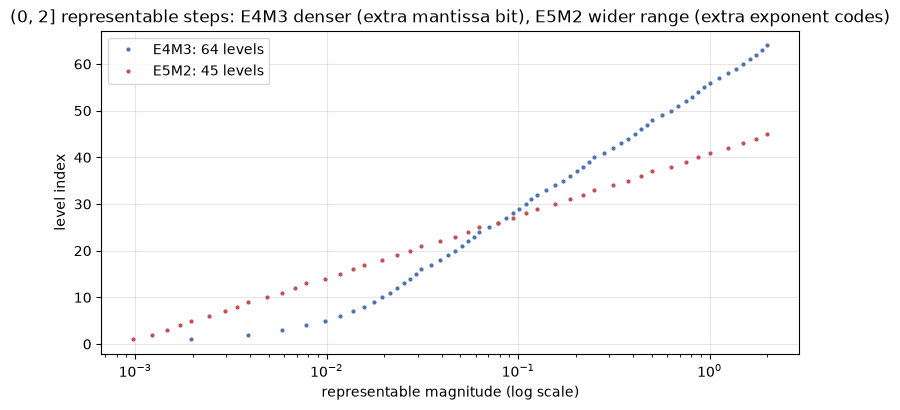

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.2))
grid = np.linspace(1e-3, 2.0, 8000)
for name, eb, mb, bs, color in [("E4M3", 4, 3, 7, "#4C72B0"),
                                ("E5M2", 5, 2, 15, "#C44E52")]:
    levels = np.unique(np.abs(quant_float(grid, eb, mb, bs, saturate=True)))
    levels = levels[levels > 0]
    ax.semilogx(levels, np.arange(1, len(levels) + 1), ".", ms=4, color=color,
                label=f"{name}: {len(levels)} levels")
ax.set_xlabel("representable magnitude (log scale)")
ax.set_ylabel("level index")
ax.set_title("(0, 2] representable steps: E4M3 denser (extra mantissa bit), "
             "E5M2 wider range (extra exponent codes)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 第 5 步 · 方法核心 Ⅱ：MXFP4 共享指数 ＋ E2M1 查表

这步在做什么：实现 Microscaling 的最小闭环——每 32 个元素一组计算一个 E8M0 共享指数 scale $s=2^{\lfloor\log_2 \mathrm{amax}\rfloor-2}$（**减 2** 是为了把组内最大元归一到 $[4,8)$，让 E2M1 的头部码级 4 和 6 真正被用上），组内元素除以 scale 后**对绝对值查 E2M1 正半轴表、再补回符号**。然后用一个跨度达 3 个数量级的病态块展示共享 scale 的威力——裸 FP4（scale$\equiv$1）会把一切大于 6 的值压扁到 6；最后现场复现两个经典 bug：① 带符号直接查正表 → 负数全映 0；② 共享指数忘减 2 → 约 7 dB 的损失。

In [5]:
E2M1_LEVELS = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])   # E2M1 正半轴全集


def mxfp4_encode(x, group=32, shared_exp=True):
    """MXFP4 编码: 返回 (codes, scale); codes 低 3 位 = E2M1 码级, 第 4 位 = 符号."""
    g = np.asarray(x, dtype=np.float64).reshape(-1, group)
    if shared_exp:
        amax = np.max(np.abs(g), axis=1)
        e_shared = np.floor(np.log2(np.maximum(amax, 1e-30))) - 2.0  # 关键: 减 2
        scale = 2.0 ** e_shared                                      # E8M0: 纯 2 的幂
    else:
        scale = np.ones(g.shape[0])                                  # 裸 FP4 对照
    u = g / scale[:, None]
    mid = (E2M1_LEVELS[:-1] + E2M1_LEVELS[1:]) / 2.0                 # 判决中点
    au = np.abs(u)                    # 坑 1: 必须对 |u| 查正表再补符号;
    idx = np.searchsorted(mid, au)    #      带符号直接查会把负数全映到 0
    codes = idx.astype(np.uint8)
    codes[np.signbit(u)] |= np.uint8(0x08)
    return codes, scale


def mxfp4_decode(codes, scale):
    """MXFP4 解码: 查表反量化 (保持分组形状)."""
    mag = E2M1_LEVELS[codes & 0x07]
    val = np.where((codes & 0x08) != 0, -mag, mag)
    return val * scale[:, None]


# ---- worked example: 跨 3 个数量级的宽动态块 ----
rng_ex = np.random.default_rng(7)
block = rng_ex.standard_normal(32) * 10.0 ** rng_ex.uniform(-1.0, 2.0, 32)
codes_mx, scale_mx = mxfp4_encode(block)
dec_mx = mxfp4_decode(codes_mx, scale_mx).ravel()
dec_bare = mxfp4_decode(*mxfp4_encode(block, shared_exp=False)).ravel()

rel_fro = lambda a, b: np.linalg.norm(a - b) / np.linalg.norm(a)   # 相对 Frobenius 误差
print(f"块 amax = {np.max(np.abs(block)):.1f}, "
      f"共享 scale = 2^{int(round(np.log2(scale_mx[0])))} (E8M0, 每组仅摊 8/32 = 0.25 bit)")
print(f"相对 Frobenius 误差:  MXFP4 = {rel_fro(block, dec_mx) * 100:.1f}%   |   "
      f"裸 FP4 (scale=1) = {rel_fro(block, dec_bare) * 100:.1f}%")
print(f"块内 SQNR:            MXFP4 = {sqnr_db(block, dec_mx):.1f} dB  |   "
      f"裸 FP4 (scale=1) = {sqnr_db(block, dec_bare):.1f} dB")

# ---- bug 现场 1: 带符号直接查正表 -> 负数全映 0 ----
mid_pts = (E2M1_LEVELS[:-1] + E2M1_LEVELS[1:]) / 2.0
u_demo = np.array([-1.3, -0.6, -0.2, 0.9, 2.7])
bad_idx = np.argmin(np.abs(E2M1_LEVELS[None, :] - u_demo[:, None]), axis=1)
good_idx = np.searchsorted(mid_pts, np.abs(u_demo))
print("\nbug 1 带符号查正表:     ", u_demo, "->", E2M1_LEVELS[bad_idx])
print("   正确 (先取 abs 再补 sign):", u_demo, "->",
      np.sign(u_demo) * E2M1_LEVELS[good_idx])


# ---- bug 现场 2: 共享指数忘减 2 -> 头部码级永远用不上 ----
def mxfp4_no_minus2(x, group=32):
    """消融对照: e_shared 忘记减 2 的错误版本."""
    g = np.asarray(x, dtype=np.float64).reshape(-1, group)
    amax = np.max(np.abs(g), axis=1)
    scale = 2.0 ** np.floor(np.log2(np.maximum(amax, 1e-30)))    # 少了 -2
    u = g / scale[:, None]
    mid = (E2M1_LEVELS[:-1] + E2M1_LEVELS[1:]) / 2.0
    idx = np.searchsorted(mid, np.abs(u))
    q = np.where(np.signbit(u), -E2M1_LEVELS[idx], E2M1_LEVELS[idx])
    return (q * scale[:, None]).reshape(x.shape)


g32 = gauss.reshape(-1, 32)
amax32 = np.max(np.abs(g32), axis=1)
u_good = np.abs(g32) / (2.0 ** (np.floor(np.log2(amax32)) - 2.0))[:, None]
u_bad = np.abs(g32) / (2.0 ** np.floor(np.log2(amax32)))[:, None]
print(f"\nbug 2 归一化后 max|u|:  正确(减 2) = {u_good.max():.2f} -> 头部码级 4/6 可用;"
      f"  忘减 2 = {u_bad.max():.2f} -> 码级 4/6 永远够不着")
sq_good = sqnr_db(gauss, mxfp4_decode(*mxfp4_encode(gauss)).reshape(gauss.shape))
sq_bad = sqnr_db(gauss, mxfp4_no_minus2(gauss))
print(f"   高斯权重 SQNR: 正确 = {sq_good:.2f} dB   忘减 2 = {sq_bad:.2f} dB"
      f"   (损失 {sq_good - sq_bad:.1f} dB)")

块 amax = 55.3, 共享 scale = 2^3 (E8M0, 每组仅摊 8/32 = 0.25 bit)
相对 Frobenius 误差:  MXFP4 = 12.2%   |   裸 FP4 (scale=1) = 81.2%
块内 SQNR:            MXFP4 = 18.3 dB  |   裸 FP4 (scale=1) = 1.8 dB

bug 1 带符号查正表:      [-1.3 -0.6 -0.2  0.9  2.7] -> [0. 0. 0. 1. 3.]
   正确 (先取 abs 再补 sign): [-1.3 -0.6 -0.2  0.9  2.7] -> [-1.5 -0.5 -0.   1.   3. ]

bug 2 归一化后 max|u|:  正确(减 2) = 8.00 -> 头部码级 4/6 可用;  忘减 2 = 2.00 -> 码级 4/6 永远够不着
   高斯权重 SQNR: 正确 = 18.79 dB   忘减 2 = 11.55 dB   (损失 7.2 dB)


## 第 6 步 · 误差评估：七种格式 SQNR 横评

这步在做什么：把七种格式放到同一张表里比 round-trip SQNR——16-bit 参照（FP16/BF16）、INT8 对称均匀量化、两种 FP8、以及两种 4-bit 方案（MXFP4 组大小 32；NF4 块大小 64）。其中 NF4 使用 QLoRA 的常数码本（标准正态等概率分位点）＋块内 absmax 归一，代表「不追求硬件友好、只追求信息论最优」的 4-bit 上限参照。最后画分组柱状图，对比两种分布下的格式排序是否一致。

format       bits/wt   gauss (dB)   laplace (dB)
-----------------------------------------------
FP16 e5m10   16.00     73.67        73.68       
BF16 e8m7    16.00     55.59        55.58       
INT8 sym     8.00      39.37        34.65       
E5M2         8.00      25.54        25.58       
E4M3         8.00      31.54        31.52       
MXFP4 grp32  4.25      18.79        17.96       
NF4 blk64    4.50      20.73        19.67       


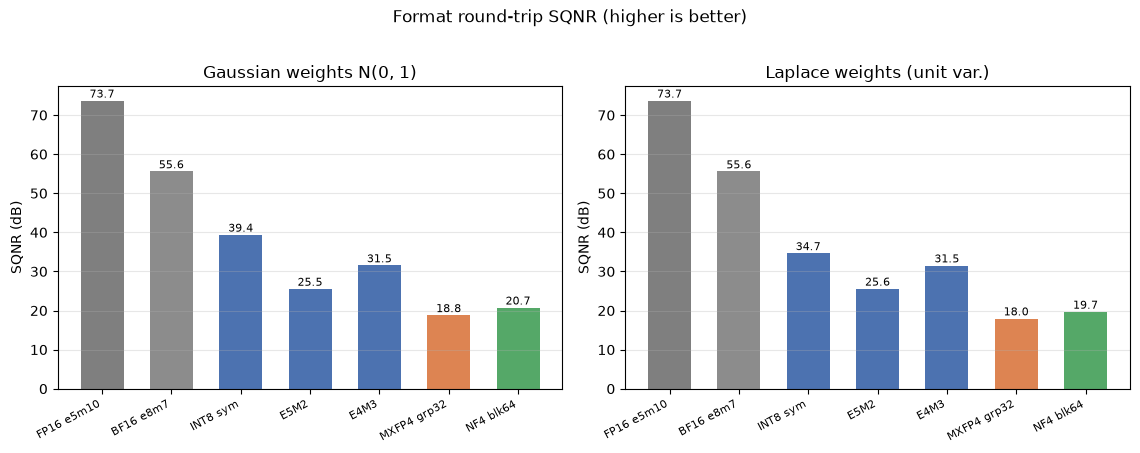

In [6]:
NF4_LEVELS = np.array([                       # QLoRA 论文的 NF4 码本 (16 级)
    -1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911, 0.0,
    0.0796, 0.1609, 0.2461, 0.3379, 0.4407, 0.5626, 0.7226, 1.0,
])


def quant_nf4(x, block=64):
    """NF4: 常数码本就近映射 + 块内 absmax 归一 (信息论最优参照)."""
    pad = (-x.size) % block
    xp = np.concatenate([x.ravel(), np.zeros(pad)])
    g = xp.reshape(-1, block)
    amax = np.max(np.abs(g), axis=1)
    scale = np.maximum(amax, 1e-30)
    u = (g / scale[:, None]).ravel()
    mid = (NF4_LEVELS[:-1] + NF4_LEVELS[1:]) / 2.0
    qg = NF4_LEVELS[np.searchsorted(mid, u)].reshape(g.shape)
    return (qg * scale[:, None]).reshape(-1)[: x.size]


FORMATS = [
    ("FP16 e5m10",  16.0,  lambda v: quant_float(v, 5, 10, 15)),
    ("BF16 e8m7",   16.0,  lambda v: quant_float(v, 8, 7, 127)),
    ("INT8 sym",     8.0,  quant_int8_sym),
    ("E5M2",         8.0,  lambda v: quant_float(v, 5, 2, 15)),
    ("E4M3",         8.0,  lambda v: quant_float(v, 4, 3, 7, saturate=True)),
    ("MXFP4 grp32",  4.25, lambda v: mxfp4_decode(*mxfp4_encode(v)).reshape(v.shape)),
    ("NF4 blk64",    4.5,  lambda v: quant_nf4(v).reshape(v.shape)),
]

results = {}
print("%-12s %-9s %-12s %-12s" % ("format", "bits/wt", "gauss (dB)", "laplace (dB)"))
print("-" * 47)
for name, bpw, fn in FORMATS:
    row = {"gauss": sqnr_db(gauss, fn(gauss)),
           "laplace": sqnr_db(laplace, fn(laplace))}
    results[name] = row
    print("%-12s %-9.2f %-12.2f %-12.2f" % (name, bpw, row["gauss"], row["laplace"]))

# ---- 分组柱状图 ----
names = [n for n, _, _ in FORMATS]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
colors = ["#7F7F7F", "#8C8C8C"] + ["#4C72B0"] * 3 + ["#DD8452", "#55A868"]
for ax, key, ttl in zip(axes, ["gauss", "laplace"],
                        ["Gaussian weights N(0, 1)", "Laplace weights (unit var.)"]):
    vals = [results[n][key] for n in names]
    bars = ax.bar(range(len(names)), vals, color=colors, width=0.62)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}",
                ha="center", fontsize=8)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=28, ha="right", fontsize=8)
    ax.set_ylabel("SQNR (dB)")
    ax.set_title(ttl)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Format round-trip SQNR (higher is better)", y=1.02)
fig.tight_layout()
plt.show()

## 结果解读

以 SEED=0、$512\times512$ 权重的实测输出为准（每次运行数字完全一致）：

1. **E4M3 比 E5M2 恰好高约 6 dB**（31.5 vs 25.5）——正是「一个尾数位」的理论增益（格点密度翻倍 $\Rightarrow$ 误差方差减半 $\Rightarrow$ $+6.02$ dB）。且注意两者的 SQNR 在高斯与拉普拉斯下几乎不变（如 E4M3 均为 $\approx31.5$）：**浮点格式的相对误差与数值大小无关**，这就是它对分布「免疫」的原因。
2. **INT8 从 39.4 dB 掉到 34.7 dB**：拉普拉斯的重尾把 absmax scale 撑大、零附近的格距随之变粗——印证了博客的观点「INT8 的精度是被 scale 绑架的假 8-bit」。FP8 用 3～5 个指数位自带跨数量级范围，不需要精细的 per-tensor scale 校准，这是它能同时量化权重与激活（W8A8）的根本原因。
3. **4-bit 阵营**：i.i.d. 数据下 NF4（20.7 / 19.7 dB）略胜 MXFP4（18.8 / 18.0 dB）——分位数码本按概率密度布点更贴近信息论最优；MXFP4 换来的则是硬件友好（E8M0 scale 只是一次移位、4.25 bit 的极低开销）与 Blackwell 原生的 W4A4 通路。
4. **共享 scale 的威力**（第 5 步 worked example）：跨 3 个数量级的宽动态块上，MXFP4 相对 Frobenius 误差仅 $\approx12\%$（块内 SQNR $\approx18$ dB），而裸 FP4 把一切大于 6 的值压扁到 6，误差高达 $\approx81\%$（SQNR 仅 $\approx2$ dB）。
5. **两个坑都真实存在**：共享指数忘减 2 让 MXFP4 从 18.8 掉到约 11.6 dB（$-7$ dB 量级），且归一化后 $\max|u|<2$、头部码级 4/6 永远够不着；带符号直接查正表则让全部负元素映射到 0。

### 方法局限

- **i.i.d. 合成数据的理想化**：真实 LLM 权重存在行间范数差异与离群结构，MXFP4 的 32 元素组内只要混入一个离群元，整组小值的分辨率就会被拖垮——这正是 DeepSeek-V3 对 FP8 采用 128×128 细粒度 block、llama.cpp 给 k-quants 配 imatrix 加权的同一逻辑；本 demo 未建模任何误差补偿算法（GPTQ/AWQ 类）。
- **只测量化噪声本身**：真实 FP8 GEMM 的误差大头还来自矩阵乘累加精度与 per-block scale 的管理策略，这里均未涉及。
- **教学约定的格式细节**：本 demo 保留最高指数码作 NaN/Inf（故 E4M3 最大有限值为 240）；OCP/NVIDIA 版 E4M3 用满全部指数码、最大有限值 448——在权重尺度的数据上两种约定 SQNR 无实质差别。
- **NF4 的适用边界**：码本隐含「标准化后近似高斯」假设，块分布偏斜时优势缩小；查表内核慢于整数运算，主流推理引擎并不用它做在线推理。

运行环境：纯 numpy ＋ matplotlib，无网络、无其他依赖；全部 cell 秒级执行完毕。